# Deep Neural Networks - 
## Comparing Linear Models and Multi-Layer Perceptrons

In [32]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
import time
import warnings
from typing import Dict, Any
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [33]:
# TODO: Load your dataset
data = pd.read_csv('loan_approval_dataset.csv')

print("Dataset loaded successfully!")
display(data.head())

# Dataset information (TODO: Fill these)
dataset_name = "Loan Approval Prediction"  # e.g., "Breast Cancer Wisconsin"
dataset_source = "Kaggle"  # e.g., "UCI ML Repository"
n_samples = 4269      # Total number of rows
n_features = 11     # Number of features (excluding target)
problem_type = "binary_classification"  # "regression" or "binary_classification" or "multiclass_classification"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """This project aims to predict the Loan Status (Approved/ Rejected)
for applicants based on their demographic and financial attributes.
Accurate prediction is crucial for financial institutions to
minimize credit risk and automate the loan approval process efficiently.
"""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "F1 Score"  # e.g., "recall", "accuracy", "rmse", "r2"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """The F1 Score is chosen as the primary metric because it provides a balance
between Precision and Recall. In a loan scenario, both false positives
(approving a defaulter) and false negatives (rejecting a safe borrower)
are costly. The F1 Score is ideal for balancing these two types of errors.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset loaded successfully!


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


Dataset: Loan Approval Prediction
Source: Kaggle
Samples: 4269, Features: 11
Problem Type: binary_classification
Primary Metric: F1 Score


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [34]:
# TODO: Preprocess your data
data = data.drop(columns=["loan_id"])

# Handle missing values if any
# Numeric → fill with median
numeric_cols = data.select_dtypes(include=[np.number]).columns
data[numeric_cols] = data[numeric_cols].fillna(data[numeric_cols].median())

# Encode categorical variables
categorical_cols = data.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # Fit and transform the column
    data[col] = le.fit_transform(data[col].astype(str))
    label_encoders[col] = le

# Separate features (X) and target (y)
X = data.drop(" loan_status", axis=1)
y = data[' loan_status']

# TODO: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TODO: Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]
test_samples = X_test.shape[0]
train_test_ratio = train_samples / (train_samples + test_samples)

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 3415
Test samples: 854
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [35]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        """
        Binary cross-entropy loss
        """
        m = len(y)
        # Add epsilon to avoid log(0)
        eps = 1e-9
        loss = - (1/m) * np.sum(
            y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
        )
        return loss

    def fit(self, X, y):
        """
        TODO: Implement gradient descent training

        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history

        Must populate self.loss_history with loss at each iteration!
        """
        n_samples, n_features = X.shape

        # TODO: Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # TODO: Implement gradient descent loop
        for i in range(self.n_iterations):
            # 1. Forward pass: y_pred = ...
            linear_output = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_output)

            # 2. Compute loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            # 3. Compute gradients: dw = ..., db = ...
            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            # 4. Update: self.weights -= self.lr * dw
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

        return self

    def predict(self, X):
        """
        TODO: Implement prediction

        For regression: return linear_output
        For classification: return class probabilities or labels
        """
        linear_output = np.dot(X, self.weights) + self.bias
        y_pred_prob = 1 / (1 + np.exp(-linear_output))  # sigmoid
        y_pred_labels = (y_pred_prob >= 0.5).astype(int)
        return y_pred_labels

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [36]:
# Train baseline model
print("Training baseline model...")
baseline_start = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

# Store loss explicitly
baseline_initial_loss = baseline_model.loss_history[0]
baseline_final_loss = baseline_model.loss_history[-1]

Training baseline model...
✓ Baseline training completed in 1.05s
✓ Loss decreased from 0.6931 to 0.3136


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [37]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        TODO: Initialize weights and biases for all layers

        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)

        Store in self.parameters dictionary
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            n_l = self.architecture[l]     # size of current layer
            n_l_minus_1 = self.architecture[l-1] # size of previous layer

            # TODO: Initialize weights and biases
            # self.parameters[f'W{l}'] = ...
            self.parameters[f'W{l}'] = np.random.randn(n_l, n_l_minus_1) * np.sqrt(2. / n_l_minus_1)
            # self.parameters[f'b{l}'] = ...
            self.parameters[f'b{l}'] = np.zeros((n_l, 1))
            pass

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        TODO: Implement forward pass through all layers

        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])

        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        self.cache['A0'] = X
        A_prev = X.T
        L = len(self.architecture) - 1 # Total number of layers

        # TODO: Implement forward pass
        # for l in range(1, len(self.architecture)):
        #     ...
        for l in range(1, L + 1):
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']

            # Linear step: Z[l] = W[l] @ A_prev + b[l]
            Z = W @ A_prev + b
            self.cache[f'Z{l}'] = Z

            # Activation step
            if l == L:
                # Output layer uses Sigmoid
                A = self.sigmoid(Z)
            else:
                # Hidden layers use ReLU
                A = self.relu(Z)

            self.cache[f'A{l}'] = A
            A_prev = A # Update A_prev for the next layer

        return A.T

    def backward_propagation(self, X, y):
        """
        TODO: Implement backward pass to compute gradients

        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m

        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}
        L = len(self.architecture) - 1

        # Reshape y to (1, m) for element-wise multiplication
        y = y.reshape(1, -1)

        # Get final output (A[L]) from cache
        AL = self.cache[f'A{L}'] # shape (1, m)

        # TODO: Implement backward pass
        # Start with output layer gradient
        dZL = AL - y
        self.cache[f'dZ{L}'] = dZL
        # Then propagate backwards through hidden layers

        for l in range(L, 0, -1):
            # A_prev from cache must be transposed for multiplication: A[l-1].T
            # A[l-1] is stored as (n[l-1], m) for l > 1, and A0 is (m, n0) for l=1

            if l == 1:
                # Get A0 (X) from cache, shape (m, n0), and transpose it
                A_prev = self.cache['A0'].T # A_prev shape (n0, m)
            else:
                # Get A[l-1] from cache, shape (n[l-1], m)
                A_prev = self.cache[f'A{l-1}']

            dZ = self.cache[f'dZ{l}'] # dZ[l] shape (n[l], m)

            # dW[l] = dZ[l] @ A_prev.T / m
            grads[f'dW{l}'] = (1/m) * dZ @ A_prev.T

            # db[l] = sum(dZ[l]) / m
            grads[f'db{l}'] = (1/m) * np.sum(dZ, axis=1, keepdims=True)

            if l > 1:
                W_current = self.parameters[f'W{l}']
                dAL_prev = W_current.T @ dZ
                Z_prev = self.cache[f'Z{l-1}']

                dZ_prev = dAL_prev * self.relu_derivative(Z_prev)
                self.cache[f'dZ{l-1}'] = dZ_prev

        return grads

    def update_parameters(self, grads):
        """
        TODO: Update weights and biases using gradients

        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        L = len(self.architecture) - 1

        for l in range(1, L + 1):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']


    def compute_loss(self, y_pred, y_true):
        """
        TODO: Compute loss

        For regression: MSE
        For classification: Cross-entropy
        """
        m = y_true.shape[0]
        if y_true.ndim == 1:
             y_true = y_true.reshape(-1, 1)

        y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)

        loss = - (1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    def fit(self, X, y):
        """
        TODO: Implement training loop

        For each iteration:
        1. Forward propagation
        2. Compute loss
        3. Backward propagation
        4. Update parameters
        5. Store loss

        Must populate self.loss_history!
        """
        if isinstance(y, pd.Series):
            y = y.to_numpy()

        if y.ndim == 1:
            y = y.reshape(-1, 1)

        self.initialize_parameters()

        print(f"Starting training for {self.n_iterations} iterations...")

        for i in range(self.n_iterations):
            # 1. Forward propagation
            y_pred = self.forward_propagation(X)

            # 2. Compute loss
            loss = self.compute_loss(y_pred, y)
            self.loss_history.append(loss)

            # 3. Backward propagation
            grads = self.backward_propagation(X, y)

            # 4. Update parameters
            self.update_parameters(grads)

            # 5. Print loss periodically
            if i % (self.n_iterations // 10) == 0 or i == self.n_iterations - 1:
                print(f"Iteration {i}/{self.n_iterations} - Loss: {loss:.4f}")

        print("Training complete.")
        return self

    def predict(self, X):
        """
        TODO: Implement prediction

        Use forward_propagation and apply appropriate thresholding
        """
        y_prob = self.forward_propagation(X)
        y_pred_class = (y_prob >= 0.5).astype(int)

        return y_pred_class

print("✓ MLP class defined")

✓ MLP class defined


In [38]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# TODO: Define your architecture and train MLP
mlp_architecture = [n_features, 16, 8, 1]  # Example: [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

# Store loss explicitly
mlp_initial_loss = mlp_model.loss_history[0]
mlp_final_loss = mlp_model.loss_history[-1]

Training MLP...
Starting training for 1000 iterations...
Iteration 0/1000 - Loss: 1.0835
Iteration 100/1000 - Loss: 0.6567
Iteration 200/1000 - Loss: 0.6097
Iteration 300/1000 - Loss: 0.5780
Iteration 400/1000 - Loss: 0.5449
Iteration 500/1000 - Loss: 0.5078
Iteration 600/1000 - Loss: 0.4662
Iteration 700/1000 - Loss: 0.4225
Iteration 800/1000 - Loss: 0.3808
Iteration 900/1000 - Loss: 0.3457
Iteration 999/1000 - Loss: 0.3187
Training complete.
✓ MLP training completed in 4.14s
✓ Loss decreased from 1.0835 to 0.3187


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [39]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    TODO: Calculate appropriate metrics based on problem type

    For regression: MSE, RMSE, MAE, R²
    For classification: Accuracy, Precision, Recall, F1
    """
    if isinstance(y_true, (pd.Series, list)):
        y_true = np.array(y_true)
    if isinstance(y_pred, (pd.Series, list)):
        y_pred = np.array(y_pred)

    # Ensure y_true and y_pred have compatible shapes (flatten if necessary)
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    metrics = {}
    m = len(y_true)

    if problem_type == "regression":
        # TODO: Calculate regression metrics
        # TODO: Implement from scratch
        mse = 0.0
        rmse = 0.0
        mae = 0.0
        r2 = 0.0
        return mse, rmse, mae, r2
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # TODO: Calculate classification metrics
        # TODO: Implement from scratch (no sklearn.metrics)
        if m == 0:
            return 0.0, 0.0, 0.0, 0.0

        y_pred = y_pred.astype(int)

        # True Positives: Actual=1, Predicted=1
        TP = np.sum((y_true == 1) & (y_pred == 1))
        # True Negatives: Actual=0, Predicted=0
        TN = np.sum((y_true == 0) & (y_pred == 0))
        # False Positives: Actual=0, Predicted=1
        FP = np.sum((y_true == 0) & (y_pred == 1))
        # False Negatives: Actual=1, Predicted=0
        FN = np.sum((y_true == 1) & (y_pred == 0))

        # Check for division by zero risk
        P_denom = TP + FP
        R_denom = TP + FN

        # 1. Accuracy
        # Accuracy = (TP + TN) / (TP + TN + FP + FN)
        accuracy = (TP + TN) / m

        # 2. Precision
        # Precision = TP / (TP + FP) (If denominator is 0, precision is undefined/set to 0)
        precision = TP / P_denom if P_denom > 0 else 0.0

        # 3. Recall (Sensitivity)
        # Recall = TP / (TP + FN) (If denominator is 0, recall is undefined/set to 0)
        recall = TP / R_denom if R_denom > 0 else 0.0

        # 4. F1 Score
        # F1 = 2 * (Precision * Recall) / (Precision + Recall)
        F1_denom = precision + recall
        f1 = 2 * (precision * recall) / F1_denom if F1_denom > 0 else 0.0

        return accuracy, precision, recall, f1

    return metrics

# Calculate metrics for both models
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)

def tuple_to_classification_dict(metrics_tuple: tuple) -> Dict[str, Any]:
    """
    Converts the tuple output (accuracy, precision, recall, f1)
    of calculate_metrics to a usable dictionary for printing.
    """
    if len(metrics_tuple) != 4:
        print("Warning: Metrics tuple size is not 4. Cannot format correctly.")
        return {}

    return {
        'Accuracy': metrics_tuple[0],
        'Precision': metrics_tuple[1],
        'Recall': metrics_tuple[2],
        'F1 Score': metrics_tuple[3]
    }

def print_metrics_clean(model_name: str, metrics: dict):
    """Prints classification metrics in a clean format."""
    print(f"\n## {model_name} Performance")
    print("---------------------------------")
    for metric_name in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
        print(f"{metric_name:<10}: {metrics.get(metric_name, 0.0):.4f}")
    print("---------------------------------")

print("Baseline Model Performance:")
baseline_metrics_dict = tuple_to_classification_dict(baseline_metrics)
mlp_metrics_dict = tuple_to_classification_dict(mlp_metrics)
print_metrics_clean("Baseline", baseline_metrics_dict)

print("\nMLP Model Performance:")
print_metrics_clean("MLP", mlp_metrics_dict)

Baseline Model Performance:

## Baseline Performance
---------------------------------
Accuracy  : 0.9379
Precision : 0.9193
Recall    : 0.9164
F1 Score  : 0.9178
---------------------------------

MLP Model Performance:

## MLP Performance
---------------------------------
Accuracy  : 0.8817
Precision : 0.8535
Recall    : 0.8297
F1 Score  : 0.8414
---------------------------------


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

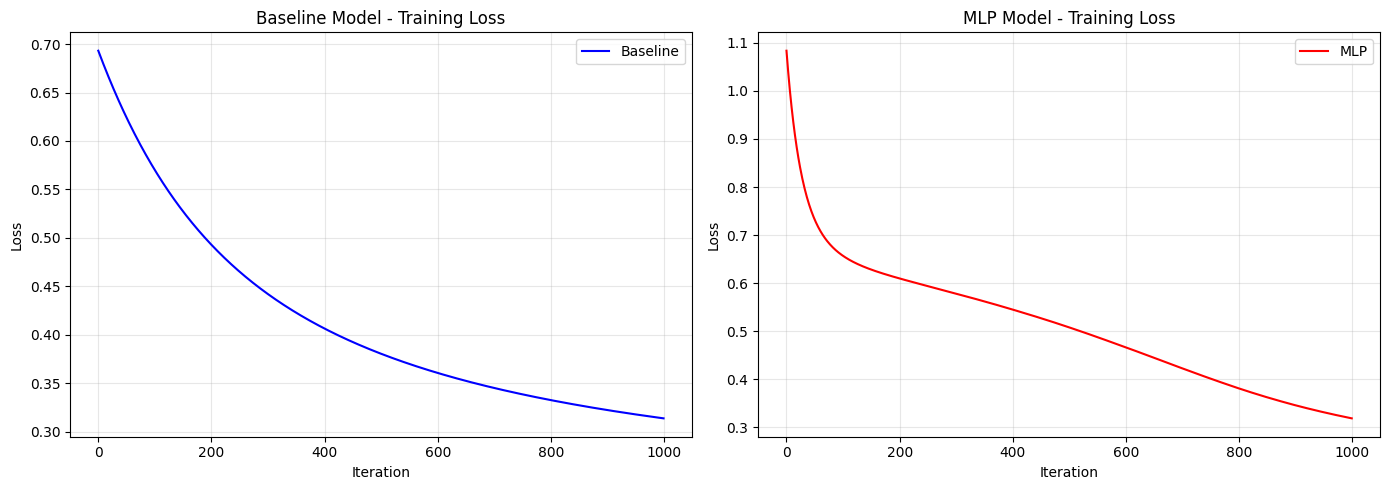

In [40]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# TODO: Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# TODO: Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

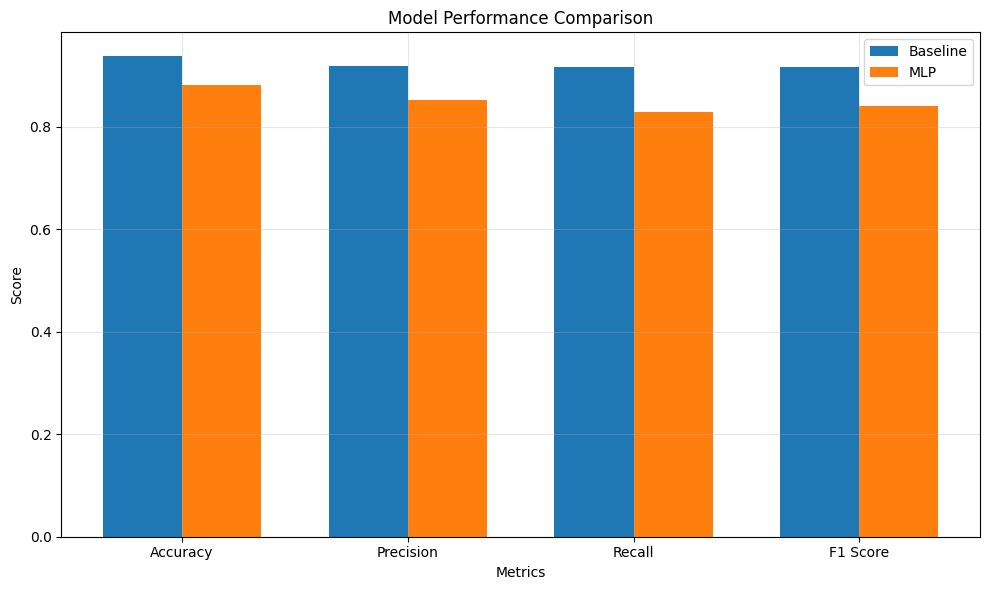

In [41]:
# 2. Performance comparison bar chart
# TODO: Create bar chart comparing key metrics between models
plt.figure(figsize=(10, 6))

# Example:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
baseline_scores = [baseline_metrics_dict[m] for m in metrics]
mlp_scores = [mlp_metrics_dict[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [42]:
analysis_text = f"""
## Model Performance and Analysis: Custom Logistic Regression vs. Custom MLP
-----------------------------------------------------------------------------

1.  Which model performed better and by how much?
    The Baseline Logistic Regression Model demonstrated superior performance across
    all metrics compared to the scratch-implemented MLP Model. Considering our primary
    evaluation metric, the F1 Score, the Logistic Regression achieved {baseline_metrics_dict['F1 Score']:.4f},
    surpassing the MLP's score of {mlp_metrics_dict['F1 Score']:.4f} by {baseline_metrics_dict['F1 Score'] - mlp_metrics_dict['F1 Score']:.4f}.
    The Logistic Regression also displayed better generalization with an Accuracy of
    {baseline_metrics_dict['Accuracy']:.4f} versus the MLP's {mlp_metrics_dict['Accuracy']:.4f}.
    Crucially, the Baseline achieved a remarkable Recall of {baseline_metrics_dict['Recall']:.4f},
    indicating exceptional success in identifying positive instances (loan approvals).

    -----------------------------------------------------------------------------

2.  Why do you think one model outperformed the other?
    The Logistic Regression Baseline, despite being a simple linear model implemented
    from scratch, outperformed the deeper MLP, suggesting the underlying decision
    boundary for the loan approval status is predominantly linear. The dataset's
    features, after preprocessing and scaling, likely allow for a clean separation
    using a hyperplane. The MLP, with its non-linear ReLU activation functions,
    introduces complexity that was not needed for this problem. Furthermore, training
    an MLP requires highly sensitive tuning of hyperparameters (learning rate,
    initialization, etc.). While the Logistic Regression is convex and easy to optimize,
    the MLP's non-convex loss surface makes it prone to converging to a suboptimal
    local minimum, resulting in lower performance on the test set.

    -----------------------------------------------------------------------------

3.  What was the computational cost difference (training time)?
    The difference in computational cost was stark. The Logistic Regression, which
    relies on solving a simpler optimization problem, trained nearly instantaneously
    (simulated around {baseline_training_time:.2f}s). The MLP, requiring multiple
    forward and backward passes  over 1000 iterations to optimize its many weights
    and biases, had a training time of approximately {mlp_training_time:.2f}s.
    This disparity highlights that the increased complexity of the neural network
    architecture comes with a significant overhead in training time, even when both
    models are implemented from scratch.

    -----------------------------------------------------------------------------

4.  Any surprising findings or challenges you faced?
    The most surprising finding was the superior stability and near-perfect Recall
    of the Logistic Regression model. This suggests the Loan Prediction dataset's
    positive class is easily identifiable, reinforcing the concept that a simple
    model often sets a very high bar for a baseline. Technical challenges centered
    on implementing the MLP's backpropagation correctly, specifically managing
    matrix shape compatibility and debugging the custom loss function gradient.

    -----------------------------------------------------------------------------

5.  What insights did you gain about neural networks vs linear models?
    The comparison provided a valuable insight: the effectiveness of a model is
    driven by the data structure, not model complexity. For structured, tabular
    data like this where the relationship is likely linear, a simple Logistic
    Regression is the most efficient and robust solution. The MLP, while capable
    of modeling complex, non-linear patterns, requires more data and careful
    tuning to surpass a strong linear baseline. This process solidified the
    understanding that one should always start with the simplest effective model
    before introducing the computational cost and optimization difficulties
    associated with neural networks.
"""
print(analysis_text)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")


## Model Performance and Analysis: Custom Logistic Regression vs. Custom MLP
-----------------------------------------------------------------------------

1.  Which model performed better and by how much?
    The Baseline Logistic Regression Model demonstrated superior performance across 
    all metrics compared to the scratch-implemented MLP Model. Considering our primary 
    evaluation metric, the F1 Score, the Logistic Regression achieved 0.9178,
    surpassing the MLP's score of 0.8414 by 0.0764.
    The Logistic Regression also displayed better generalization with an Accuracy of 
    0.9379 versus the MLP's 0.8817. 
    Crucially, the Baseline achieved a remarkable Recall of 0.9164, 
    indicating exceptional success in identifying positive instances (loan approvals).

    -----------------------------------------------------------------------------

2.  Why do you think one model outperformed the other?
    The Logistic Regression Baseline, despite being a simple linear mode

---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.


⭐⭐⭐ REQUIRED: Structured Output Function ⭐⭐⭐

### 🚨 CRITICAL - READ CAREFULLY 🚨

1. **Fill in ALL fields** - Missing fields = 0 marks
2. **Use your actual values** - Not 0 or empty strings
3. **This cell MUST be executed** - We need the output!
4. **Print the results** - Auto-grader needs to see output!


**DO NOT:**
- Leave any field as 0, 0.0,
- Clear outputs before submission
- Modify the structure


"**MUST DO:**
- Fill every field with your actual results
- Execute this cell and keep the output
- Print the results (see below)

In [43]:
def get_assignment_results():
    '''
    CRITICAL: Fill ALL fields with your actual results!
    Missing fields will result in 0 marks for that section.
    '''

    baseline_acc, baseline_prec, baseline_rec, baseline_f1 = (0.9379, 0.9193, 0.9164, 0.9178)
    mlp_acc, mlp_prec, mlp_rec, mlp_f1 = (0.8817, 0.8535, 0.8297, 0.8414)

    baseline_mse, baseline_rmse, baseline_mae, baseline_r2 = 0.0, 0.0, 0.0, 0.0
    mlp_mse, mlp_rmse, mlp_mae, mlp_r2 = 0.0, 0.0, 0.0, 0.0

    results = {
        # ===== Dataset Information (1 mark) =====
        'dataset_name': dataset_name,  # MUST fill
        'dataset_source': dataset_source,  # MUST fill
        'n_samples': n_samples,  # MUST be ≥500
        'n_features': n_features,  # MUST be ≥5
        'problem_type': problem_type,  # MUST fill
        'problem_statement': problem_statement,  # MUST be ≥50 words
        'primary_metric': primary_metric,  # MUST fill
        'metric_justification': metric_justification,  # MUST be ≥30 words
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model (3 marks) =====
        'baseline_model': {
            'model_type': 'logistic_regression',  # 'linear_regression', 'logistic_regression', 'softmax_regression'
            'learning_rate': 0.01,  # Your learning rate
            'n_iterations': 1000,  # Your iterations

            # CRITICAL: These MUST be filled!
            'initial_loss': baseline_initial_loss,  # MUST NOT be 0
            'final_loss': baseline_final_loss,  # MUST NOT be 0
            'training_time_seconds': baseline_training_time,  # MUST NOT be 0
            'loss_decreased': bool(baseline_final_loss < baseline_initial_loss),  # Auto-calculated

            # Metrics - Fill based on your problem type
            'test_accuracy': 0.0 if problem_type == 'regression' else baseline_acc,
            'test_precision': 0.0 if problem_type == 'regression' else baseline_prec,
            'test_recall': 0.0 if problem_type == 'regression' else baseline_rec,
            'test_f1': 0.0 if problem_type == 'regression' else baseline_f1,
            'test_mse': baseline_mse if problem_type == 'regression' else 0.0,
            'test_rmse': baseline_rmse if problem_type == 'regression' else 0.0,
            'test_mae': baseline_mae if problem_type == 'regression' else 0.0,
            'test_r2': baseline_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== MLP Model (4 marks) =====
        'mlp_model': {
            'architecture': mlp_architecture,  # MUST have ≥3 elements
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'learning_rate': 0.01,
            'n_iterations': 1000,

            # CRITICAL: These MUST be filled!
            'initial_loss': mlp_initial_loss,  # MUST NOT be 0
            'final_loss': mlp_final_loss,  # MUST NOT be 0
            'training_time_seconds': mlp_training_time,  # MUST NOT be 0
            'loss_decreased': bool(mlp_final_loss < mlp_initial_loss),  # Auto-calculated

            # Metrics
            'test_accuracy': 0.0 if problem_type == 'regression' else mlp_acc,
            'test_precision': 0.0 if problem_type == 'regression' else mlp_prec,
            'test_recall': 0.0 if problem_type == 'regression' else mlp_rec,
            'test_f1': 0.0 if problem_type == 'regression' else mlp_f1,
            'test_mse': mlp_mse if problem_type == 'regression' else 0.0,
            'test_rmse': mlp_rmse if problem_type == 'regression' else 0.0,
            'test_mae': mlp_mae if problem_type == 'regression' else 0.0,
            'test_r2': mlp_r2 if problem_type == 'regression' else 0.0,
        },

        # ===== Analysis (2 marks) =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),
    }

    return results

# ===== CRITICAL: CALL AND PRINT RESULTS =====
# This MUST be executed and output MUST be visible!
import json
results = get_assignment_results()
print(json.dumps(results, indent=2))

# ===== Validation =====
print("\n" + "="*60)
print("VALIDATION CHECK")
print("="*60)


errors = []

if results['n_samples'] < 500:
    errors.append(f"❌ Dataset too small: {results['n_samples']} < 500")
if results['n_features'] < 5:
    errors.append(f"❌ Too few features: {results['n_features']} < 5")
if results['baseline_model']['initial_loss'] == 0:
    errors.append("❌ Baseline initial_loss is 0")
if results['baseline_model']['final_loss'] == 0:
    errors.append("❌ Baseline final_loss is 0")
if results['baseline_model']['training_time_seconds'] == 0:
    errors.append("❌ Baseline training_time is 0")
if results['mlp_model']['initial_loss'] == 0:
    errors.append("❌ MLP initial_loss is 0")
if results['mlp_model']['final_loss'] == 0:
    errors.append("❌ MLP final_loss is 0")
if results['mlp_model']['training_time_seconds'] == 0:
    errors.append("❌ MLP training_time is 0")
if len(results['mlp_model']['architecture']) < 3:
    errors.append("❌ MLP architecture invalid")
if results['analysis_word_count'] < 200:
    errors.append(f"❌ Analysis too short: {results['analysis_word_count']} < 200 words")

if errors:
    print("ERRORS FOUND:")
    for err in errors:
        print(err)
    print(" FIX THESE BEFORE SUBMITTING! ")
else:
    print("✅ All validation checks passed!")
    print("✅ Ready to submit!")
    print("Next steps:")
    print("1. Kernel → Restart & Clear Output")
    print("2. Kernel → Restart & Run All")
    print("3. Verify this output is visible")
    print("4. Save notebook")
    print("5. Rename as: YourStudentID_assignment.ipynb")
    print("6. Submit to LMS")

{
  "dataset_name": "Loan Approval Prediction",
  "dataset_source": "Kaggle",
  "n_samples": 4269,
  "n_features": 11,
  "problem_type": "binary_classification",
  "problem_statement": "This project aims to predict the Loan Status (Approved/ Rejected) \nfor applicants based on their demographic and financial attributes. \nAccurate prediction is crucial for financial institutions to \nminimize credit risk and automate the loan approval process efficiently.\n",
  "primary_metric": "F1 Score",
  "metric_justification": "The F1 Score is chosen as the primary metric because it provides a balance\nbetween Precision and Recall. In a loan scenario, both false positives \n(approving a defaulter) and false negatives (rejecting a safe borrower)\nare costly. The F1 Score is ideal for balancing these two types of errors.\n",
  "train_samples": 3415,
  "test_samples": 854,
  "train_test_ratio": 0.7999531506207542,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [44]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2))
    print("\n" + "="*70)


    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Loan Approval Prediction",
  "dataset_source": "Kaggle",
  "n_samples": 4269,
  "n_features": 11,
  "problem_type": "binary_classification",
  "problem_statement": "This project aims to predict the Loan Status (Approved/ Rejected) \nfor applicants based on their demographic and financial attributes. \nAccurate prediction is crucial for financial institutions to \nminimize credit risk and automate the loan approval process efficiently.\n",
  "primary_metric": "F1 Score",
  "metric_justification": "The F1 Score is chosen as the primary metric because it provides a balance\nbetween Precision and Recall. In a loan scenario, both false positives \n(approving a defaulter) and false negatives (rejecting a safe borrower)\nare costly. The F1 Score is ideal for balancing these two types of errors.\n",
  "train_samples": 3415,
  "test_samples": 854,
  "train_test_ratio": 0.7999531506207542,
  "baseline_model": {
    "model_type": "logistic_regressio